# Modeler - Entrenamiento y evaluacion de modelos de churn

Notebook de modelado del TP3. Recibe las features ya transformadas (`features_train.parquet`, `features_test.parquet`) generadas por el notebook 3 (Training) y produce:

- **Baseline**: `DummyClassifier(strategy='most_frequent')`
- **Modelo potente**: `RandomForestClassifier` + GridSearchCV
- **Analisis SHAP** sobre Random Forest
- **Evaluacion final** en test set: matriz de confusion, precision, recall, F1, ROC-AUC y PR-AUC

El test set solo se toca en la seccion de evaluacion final (seccion 6).

## 0. Setup

In [1]:
from pathlib import Path
import json
import sys
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    fbeta_score,
    make_scorer,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
)

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

FEATURES_TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "features_train.parquet"
FEATURES_TEST_PATH  = PROJECT_ROOT / "data" / "processed" / "features_test.parquet"
TARGET_TRAIN_PATH   = PROJECT_ROOT / "data" / "processed" / "target_train.csv"
TARGET_TEST_PATH    = PROJECT_ROOT / "data" / "processed" / "target_test.csv"
MODELS_OUTPUT_DIR   = PROJECT_ROOT / "outputs" / "models"
MODELS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
F2_SCORER = make_scorer(fbeta_score, beta=2, zero_division=0)
SCORING = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "f2": F2_SCORER,
}


## 1. Ingenieria de features

El pipeline (`src/features/pipeline.py`) ya aplico las transformaciones sobre el split de entrenamiento. Las 38 columnas del parquet son:

| Grupo | Cantidad | Detalle |
|---|---|---|
| Numericas base | 12 | Variables originales del dataset menos `DaySinceLastOrder` |
| Numericas derivadas | 4 | Features de negocio construidas a partir del EDA |
| Segmentacion binaria | 5 | Flags de ciclo de vida y frecuencia del cliente |
| Categoricas OHE | 17 | 5 variables categoricas expandidas con One-Hot Encoding |

**Features derivadas (decision de negocio):**

- `valor_cliente_proxy` = `OrderCount` * `CashbackAmount` — estima el valor economico del cliente segun volumen y cashback acumulado.
- `coupon_per_order` = `CouponUsed` / `OrderCount` — intensidad de uso de cupones por orden; separa clientes que usan cupones sistematicamente de los ocasionales.
- `cashback_per_order` = `CashbackAmount` / `OrderCount` — cashback promedio por orden; normaliza el beneficio por nivel de actividad.
- `complain_x_satisfaction` = `Complain` * `SatisfactionScore` — interaccion directa de H7: captura el efecto combinado de tener reclamo con nivel de satisfaccion.

**Flags de segmentacion binaria (Decision 29):**

- `is_new_customer` = Tenure <= 3 meses — ventana de mayor riesgo de churn temprano.
- `is_loyal_customer` = Tenure >= 18 meses — cliente establecido / senior.
- `is_low_freq_user` = OrderCount <= Q25 train — baja frecuencia de compra.
- `is_high_freq_user` = OrderCount >= Q75 train — alta frecuencia de compra.
- `is_high_value` = CashbackAmount >= mediana train — proxy de alto valor economico.

`DaySinceLastOrder` fue excluida del modelo (Decision 15): es retroactiva y no sirve como señal de alerta temprana en produccion.

In [2]:
from src.features.pipeline import (
    BASE_NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    DERIVED_NUMERIC_FEATURES,
    NUMERIC_FEATURES,
)

X_train = pd.read_parquet(FEATURES_TRAIN_PATH)
X_test  = pd.read_parquet(FEATURES_TEST_PATH)
y_train = pd.read_csv(TARGET_TRAIN_PATH)["Churn"].values
y_test  = pd.read_csv(TARGET_TEST_PATH)["Churn"].values

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train churn rate: {y_train.mean():.3%}")
print(f"y_test  churn rate: {y_test.mean():.3%}")
print()
print("Features numericas base:", BASE_NUMERIC_FEATURES)
print()
print("Features numericas derivadas:", DERIVED_NUMERIC_FEATURES)
print()
print("Features categoricas:", CATEGORICAL_FEATURES)
print()
print(f"Total columnas: {X_train.shape[1]}")


X_train: (4059, 38)
X_test:  (1015, 38)
y_train churn rate: 16.580%
y_test  churn rate: 16.552%

Features numericas base: ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'CashbackAmount']

Features numericas derivadas: ['valor_cliente_proxy', 'coupon_per_order', 'cashback_per_order', 'complain_x_satisfaction']

Features categoricas: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

Total columnas: 38


## 1.1 Feature de clusterizacion K-Means (Decision 30)

Se agrega la pertenencia al cluster K-Means como feature numerica entera. El ajuste se hace **solo sobre `X_train`** para evitar leakage; la prediccion de cluster sobre `X_test` usa el modelo ya entrenado.

Se usan 16 features numericas escaladas (`BASE_NUMERIC_FEATURES + DERIVED_NUMERIC_FEATURES`) para construir la distancia euclidea. Las flags binarias (`is_*`) se excluyen porque representan reglas de segmentacion derivadas de variables ya incluidas, y las columnas OHE se excluyen para evitar que indicadores categoricos dispersos dominen artificialmente la distancia.

El numero de clusters se elige por coeficiente de silueta (k=2 a k=5); se prefiere el k con mayor silueta siempre que sea bajo e interpretable.

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Features continuas ya escaladas por RobustScaler (excluye flags binarios y OHE)
KMEANS_COLS = BASE_NUMERIC_FEATURES + DERIVED_NUMERIC_FEATURES

sil_scores = {}
for k in range(2, 6):
    km_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_tmp = km_tmp.fit_predict(X_train[KMEANS_COLS])
    sil_scores[k] = silhouette_score(X_train[KMEANS_COLS], labels_tmp)

print("Coeficiente de silueta por k (X_train, features continuas escaladas):")
for k, s in sil_scores.items():
    marker = " <-- elegido" if k == max(sil_scores, key=sil_scores.get) else ""
    print(f"  k={k}: {s:.4f}{marker}")

BEST_K = max(sil_scores, key=sil_scores.get)

Coeficiente de silueta por k (X_train, features continuas escaladas):
  k=2: 0.4293 <-- elegido
  k=3: 0.2581
  k=4: 0.2619
  k=5: 0.1665


In [4]:
km_final = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=10)
km_final.fit(X_train[KMEANS_COLS])

X_train = X_train.copy()
X_test  = X_test.copy()
X_train["kmeans_cluster"] = km_final.labels_
X_test["kmeans_cluster"]  = km_final.predict(X_test[KMEANS_COLS])

print(f"K-Means k={BEST_K} ajustado sobre X_train. Feature 'kmeans_cluster' agregada.")
print(f"Distribucion train: {pd.Series(X_train['kmeans_cluster']).value_counts().sort_index().to_dict()}")
print(f"Distribucion test:  {pd.Series(X_test['kmeans_cluster']).value_counts().sort_index().to_dict()}")
print(f"Total columnas: X_train={X_train.shape[1]}, X_test={X_test.shape[1]}")

K-Means k=2 ajustado sobre X_train. Feature 'kmeans_cluster' agregada.
Distribucion train: {0: 3426, 1: 633}
Distribucion test:  {0: 853, 1: 162}
Total columnas: X_train=39, X_test=39


## 2. Baseline: DummyClassifier

Se usa `DummyClassifier(strategy='most_frequent')`, que siempre predice la clase mayoritaria (`Churn=0`). Es un baseline ingenuo y reproducible: establece el piso minimo que un modelo predictivo debe superar.

Se evalua con cross-validation estratificada de 5 folds y las mismas metricas que el Random Forest. Accuracy no se usa como metrica principal: este dummy alcanza cerca de 83% prediciendo "nadie churna", pero tiene recall, precision, F1 y F2 iguales a cero para la clase positiva. Su PR-AUC coincide aproximadamente con la prevalencia de churn y funciona como referencia para esta metrica.

In [5]:
dummy_baseline = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE,
)

cv_baseline = cross_validate(
    dummy_baseline, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=-1
)

print("DummyClassifier - most_frequent (CV 5-fold):")
print("-" * 40)
for metric in SCORING:
    scores = cv_baseline[f"test_{metric}"]
    print(f"  {metric:12s}: {scores.mean():.4f} (+/- {scores.std():.4f})")


DummyClassifier - most_frequent (CV 5-fold):
----------------------------------------
  roc_auc     : 0.5000 (+/- 0.0000)
  pr_auc      : 0.1658 (+/- 0.0006)
  f1          : 0.0000 (+/- 0.0000)
  recall      : 0.0000 (+/- 0.0000)
  precision   : 0.0000 (+/- 0.0000)
  f2          : 0.0000 (+/- 0.0000)


## 3. Random Forest con GridSearchCV

El Random Forest se regulariza para controlar overfitting. La grilla evita arboles completamente libres (`max_depth=None`) y hojas de una sola observacion. Los hiperparametros se seleccionan maximizando PR-AUC (`average_precision`) en validacion cruzada, porque churn es la clase minoritaria de interes.

Se mantiene `max_features='sqrt'` para diversificar los arboles y se agrega `max_samples` para que cada arbol vea una submuestra bootstrap del train.

In [6]:
rf_params = {
    "n_estimators": [200],
    "max_depth": [6, 8, 10, 12],
    "min_samples_leaf": [5, 10, 20],
    "min_samples_split": [10, 20, 40],
    "max_features": ["sqrt"],
    "class_weight": ["balanced", "balanced_subsample"],
    "max_samples": [0.70, 0.85],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(
        random_state=RANDOM_STATE,
        bootstrap=True,
    ),
    rf_params,
    cv=CV,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
best_rf_idx = grid_rf.best_index_
rf_train_pr_auc = grid_rf.cv_results_["mean_train_score"][best_rf_idx]
rf_cv_pr_auc = grid_rf.cv_results_["mean_test_score"][best_rf_idx]
rf_gap_pr_auc = rf_train_pr_auc - rf_cv_pr_auc

print(f"Mejor PR-AUC train (CV interno): {rf_train_pr_auc:.4f}")
print(f"Mejor PR-AUC validacion (CV): {rf_cv_pr_auc:.4f}")
print(f"Gap train-CV PR-AUC: {rf_gap_pr_auc:.4f}")
print(f"Mejores parametros: {grid_rf.best_params_}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits


Mejor PR-AUC train (CV interno): 0.9467
Mejor PR-AUC validacion (CV): 0.8122
Gap train-CV PR-AUC: 0.1345
Mejores parametros: {'class_weight': 'balanced_subsample', 'max_depth': 12, 'max_features': 'sqrt', 'max_samples': 0.85, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}


## 4. Comparacion de modelos

Se comparan el DummyClassifier y el Random Forest usando las mismas metricas CV para un juicio justo. PR-AUC complementa ROC-AUC porque se concentra en la calidad de deteccion de la clase positiva minoritaria. El test set todavia no se toca.

Ademas se reporta el gap train-CV del Random Forest regularizado para controlar que el modelo no este memorizando el train.

In [7]:
cv_best_rf = cross_validate(
    best_rf,
    X_train,
    y_train,
    cv=CV,
    scoring=SCORING,
    n_jobs=-1,
    return_train_score=True,
)

comparison = {}
for label, cv_res in [
    ("DummyClassifier (most_frequent)", cv_baseline),
    ("RF regularizado", cv_best_rf),
]:
    comparison[label] = {
        metric: round(cv_res[f"test_{metric}"].mean(), 4) for metric in SCORING
    }

comparison_df = pd.DataFrame(comparison).T
comparison_df.index.name = "modelo"
print("Comparacion CV 5-fold (medias):")
print(comparison_df.to_string())

rf_overfit_check = pd.DataFrame({
    "train_mean": {
        metric: cv_best_rf[f"train_{metric}"].mean() for metric in SCORING
    },
    "cv_mean": {
        metric: cv_best_rf[f"test_{metric}"].mean() for metric in SCORING
    },
})
rf_overfit_check["gap_train_cv"] = (
    rf_overfit_check["train_mean"] - rf_overfit_check["cv_mean"]
)

print("\nChequeo overfitting RF regularizado (train vs CV):")
print(rf_overfit_check.round(4).to_string())

Comparacion CV 5-fold (medias):
                                 roc_auc  pr_auc      f1  recall  precision      f2
modelo                                                                             
DummyClassifier (most_frequent)   0.5000  0.1658  0.0000  0.0000     0.0000  0.0000
RF regularizado                   0.9485  0.8122  0.7282  0.7741     0.6882  0.7549

Chequeo overfitting RF regularizado (train vs CV):
           train_mean  cv_mean  gap_train_cv
roc_auc        0.9892   0.9485        0.0407
pr_auc         0.9467   0.8122        0.1345
f1             0.8605   0.7282        0.1323
recall         0.9428   0.7741        0.1687
precision      0.7915   0.6882        0.1033
f2             0.9081   0.7549        0.1531


## 5. Analisis SHAP (Random Forest regularizado final)

SHAP explica como el Random Forest usa las variables para producir sus predicciones; no demuestra relaciones causales sobre el fenomeno de churn. Visualizaciones:

- **Summary plot**: distribucion global de impacto por feature
- **Bar plot**: importancia media absoluta (para audiencia no tecnica)
- **Waterfall plot**: desglose de un caso concreto de churn detectado

In [8]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# shap_values es lista [class0_array, class1_array] para clasificacion binaria
sv_churn = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]
ev_churn = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
)

print(f"SHAP values shape (clase churn): {sv_churn.shape}")
print(f"Expected value (clase churn): {ev_churn:.4f}")


SHAP values shape (clase churn): (1015, 39)
Expected value (clase churn): 0.5000


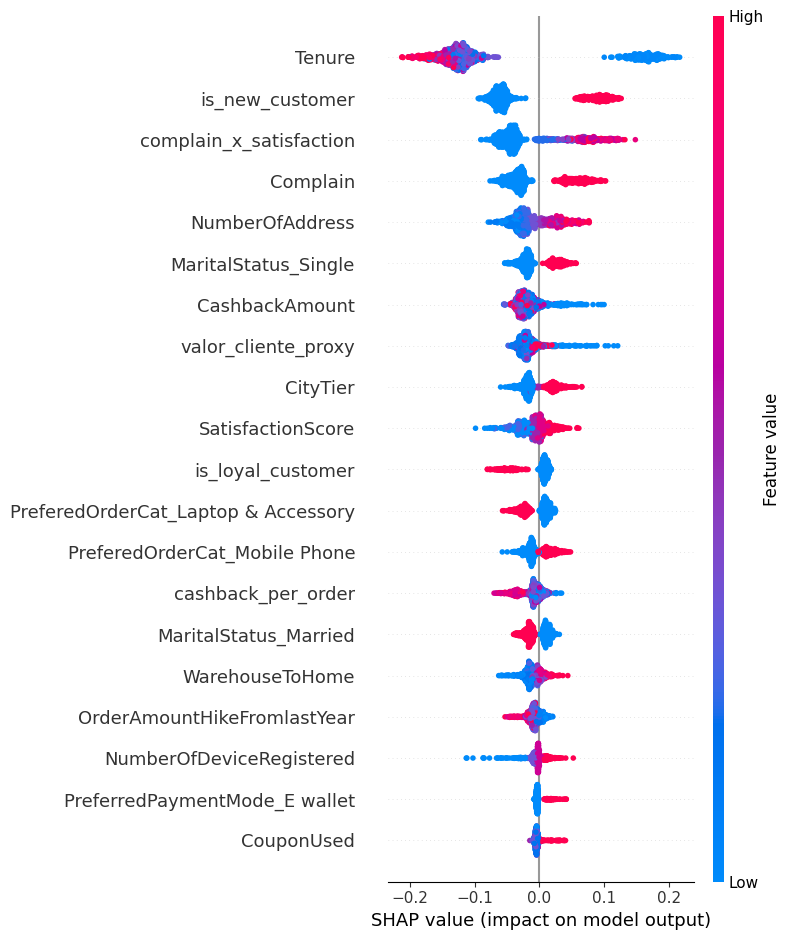

Guardado: shap_summary.png


In [9]:
# Summary plot: dot cloud (distribucion de impacto por feature)
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(sv_churn, X_test, show=False)
plt.tight_layout()
plt.savefig(MODELS_OUTPUT_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: shap_summary.png")


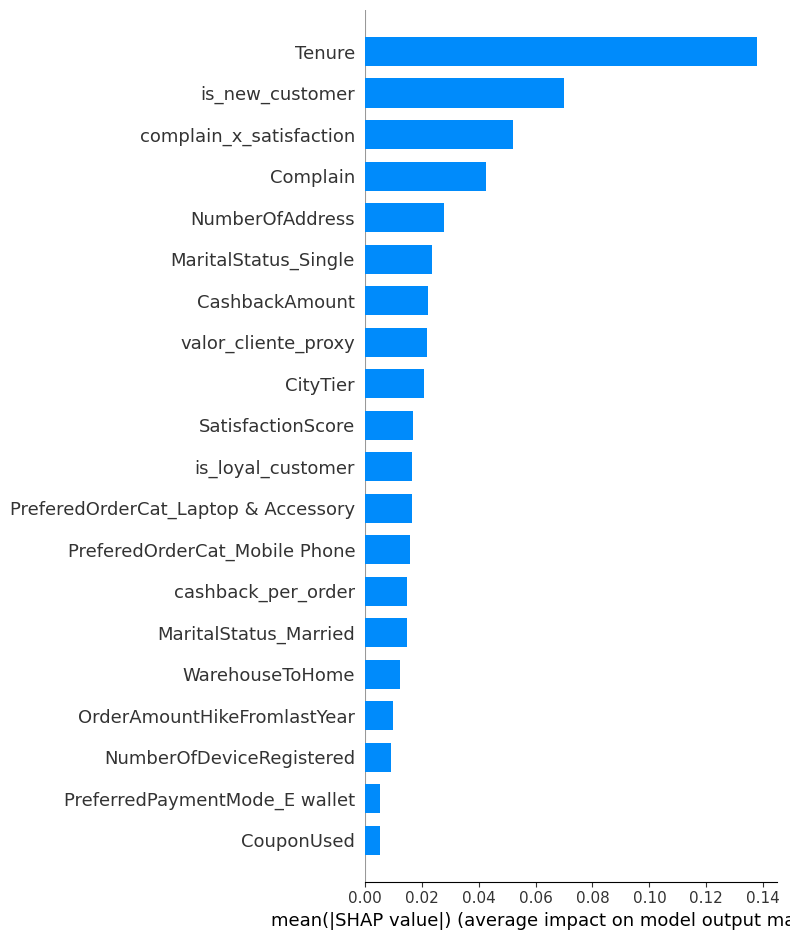

Guardado: shap_bar.png


In [10]:
# Bar plot: importancia media absoluta
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(sv_churn, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig(MODELS_OUTPUT_DIR / "shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: shap_bar.png")


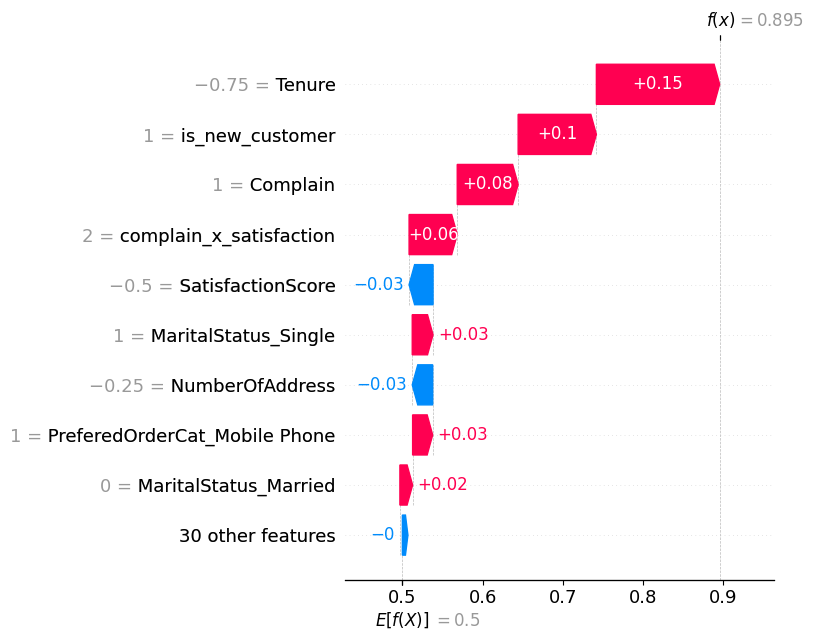

Waterfall para test idx=1 (verdadero positivo). Guardado.


In [11]:
# Waterfall plot: caso concreto de verdadero positivo
y_pred_rf = best_rf.predict(X_test)
tp_mask = (y_pred_rf == 1) & (y_test == 1)
example_idx = int(np.where(tp_mask)[0][0])

explanation_sample = shap.Explanation(
    values=sv_churn[example_idx],
    base_values=ev_churn,
    data=X_test.values[example_idx],
    feature_names=list(X_test.columns),
)
fig = plt.figure(figsize=(12, 7))
shap.plots.waterfall(explanation_sample, show=False)
plt.tight_layout()
plt.savefig(MODELS_OUTPUT_DIR / "shap_waterfall_example.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Waterfall para test idx={example_idx} (verdadero positivo). Guardado.")


## 6. Evaluacion final en test set

El test set se usa una sola vez aqui para medir el resultado final. El umbral F2 se calibra antes con probabilidades out-of-fold generadas por cross-validation sobre `X_train`, porque el objetivo de negocio prioriza recall sobre precision sin optimizar el corte mirando el test. ROC-AUC y PR-AUC se calculan sobre probabilidades y no dependen del umbral elegido.


Beta usado para calibrar umbral: 2
Umbral F2 calibrado con CV out-of-fold: 0.291
CV out-of-fold - F2: 0.8060 | precision=0.5092 | recall=0.9435
Test final - F2: 0.8165 | precision=0.5062 | recall=0.9643
Umbral guardado en: outputs\models\threshold_f2_cv.json


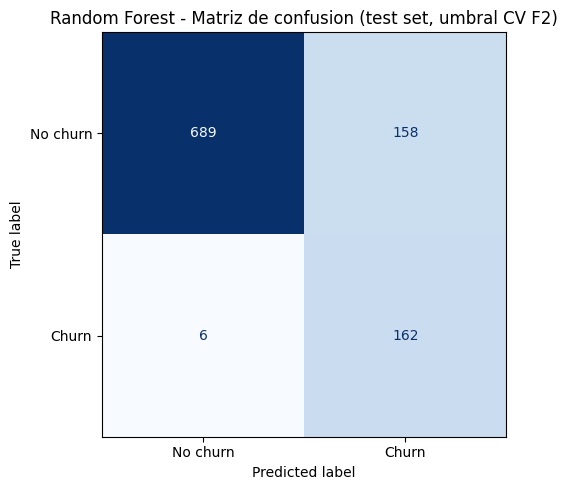

In [12]:
from sklearn.metrics import fbeta_score, precision_score, recall_score

BETA = 2.0

# Probabilidades out-of-fold: cada fila de train se predice con un modelo que no vio esa fila.
y_proba_threshold_oof = cross_val_predict(
    clone(best_rf),
    X_train,
    y_train,
    cv=CV,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

threshold_candidates = np.unique(np.r_[np.linspace(0, 1, 1001), y_proba_threshold_oof])
threshold_rows = []
for threshold in threshold_candidates:
    y_pred_threshold = (y_proba_threshold_oof >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "fbeta": fbeta_score(y_train, y_pred_threshold, beta=BETA, zero_division=0),
        "precision": precision_score(y_train, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_train, y_pred_threshold, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_df.sort_values(
    ["fbeta", "recall", "precision", "threshold"], ascending=False
).iloc[0]

THRESHOLD_F2 = float(best_threshold_row["threshold"])
cv_threshold_metrics = {
    "beta": BETA,
    "threshold": THRESHOLD_F2,
    "fbeta_cv_oof": float(best_threshold_row["fbeta"]),
    "precision_cv_oof": float(best_threshold_row["precision"]),
    "recall_cv_oof": float(best_threshold_row["recall"]),
    "cv_folds": CV.get_n_splits(),
    "cv_size": int(len(y_train)),
    "cv_churners": int(y_train.sum()),
}

threshold_config_path = MODELS_OUTPUT_DIR / "threshold_f2_cv.json"
with open(threshold_config_path, "w", encoding="utf-8") as f:
    json.dump(cv_threshold_metrics, f, indent=2)

y_proba_final = best_rf.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_final >= THRESHOLD_F2).astype(int)

test_precision = precision_score(y_test, y_pred_final, zero_division=0)
test_recall = recall_score(y_test, y_pred_final, zero_division=0)
test_fbeta = fbeta_score(y_test, y_pred_final, beta=BETA, zero_division=0)

print(f"Beta usado para calibrar umbral: {BETA:g}")
print(f"Umbral F{BETA:g} calibrado con CV out-of-fold: {THRESHOLD_F2:.3f}")
print(
    f"CV out-of-fold - F{BETA:g}: {best_threshold_row['fbeta']:.4f} | "
    f"precision={best_threshold_row['precision']:.4f} | recall={best_threshold_row['recall']:.4f}"
)
print(
    f"Test final - F{BETA:g}: {test_fbeta:.4f} | "
    f"precision={test_precision:.4f} | recall={test_recall:.4f}"
)
print(f"Umbral guardado en: {threshold_config_path.relative_to(PROJECT_ROOT)}")

# Matriz de confusion
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    ax=ax,
    display_labels=["No churn", "Churn"],
    colorbar=False,
    cmap="Blues",
)
plt.title(f"Random Forest - Matriz de confusion (test set, umbral CV F{BETA:g})")
plt.tight_layout()
plt.savefig(MODELS_OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


In [13]:
# Metricas por clase con umbral F2
print("Reporte de clasificacion (test set, umbral F2):")
print(classification_report(y_test, y_pred_final, target_names=["No churn", "Churn"]))

roc_auc = roc_auc_score(y_test, y_proba_final)
pr_auc = average_precision_score(y_test, y_proba_final)
print(f"ROC-AUC (test): {roc_auc:.4f}")
print(f"PR-AUC (test):  {pr_auc:.4f}")


Reporte de clasificacion (test set, umbral F2):
              precision    recall  f1-score   support

    No churn       0.99      0.81      0.89       847
       Churn       0.51      0.96      0.66       168

    accuracy                           0.84      1015
   macro avg       0.75      0.89      0.78      1015
weighted avg       0.91      0.84      0.86      1015

ROC-AUC (test): 0.9515
PR-AUC (test):  0.8362


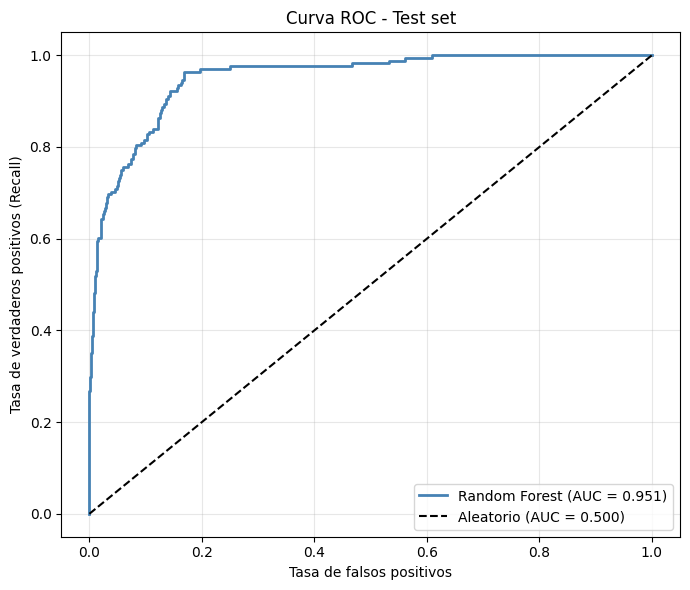

Guardado: roc_curve.png


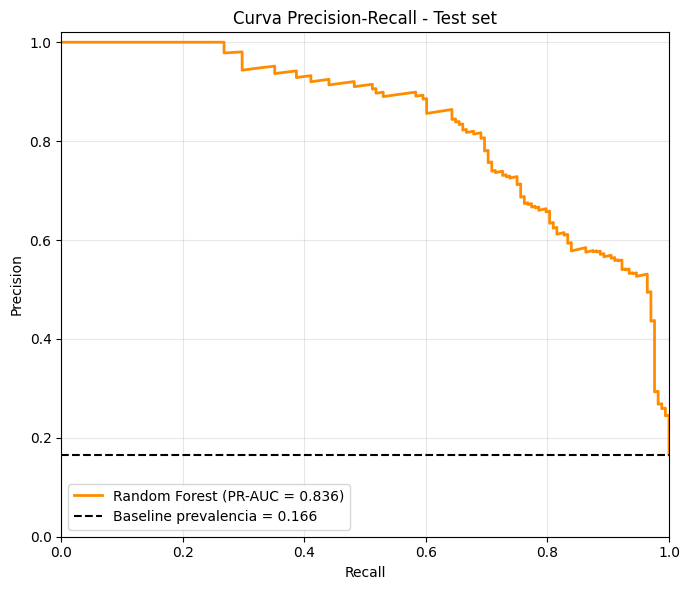

Guardado: precision_recall_curve.png


In [14]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_final)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"Random Forest (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Aleatorio (AUC = 0.500)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos (Recall)")
ax.set_title("Curva ROC - Test set")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_OUTPUT_DIR / "roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: roc_curve.png")

# Curva Precision-Recall
pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_proba_final)
prevalence = float(np.mean(y_test))

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(pr_recall, pr_precision, color="darkorange", lw=2, label=f"Random Forest (PR-AUC = {pr_auc:.3f})")
ax.axhline(prevalence, color="black", ls="--", lw=1.5, label=f"Baseline prevalencia = {prevalence:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall - Test set")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_OUTPUT_DIR / "precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: precision_recall_curve.png")


In [15]:
# Comparacion DummyClassifier vs RF regularizado en test set
dummy_baseline.fit(X_train, y_train)
y_pred_dummy = dummy_baseline.predict(X_test)
y_proba_dummy = dummy_baseline.predict_proba(X_test)[:, 1]

from sklearn.metrics import f1_score, precision_score, recall_score

test_results = pd.DataFrame({
    "DummyClassifier (most_frequent)": {
        "roc_auc": roc_auc_score(y_test, y_proba_dummy),
        "pr_auc":  average_precision_score(y_test, y_proba_dummy),
        "f1":       f1_score(y_test, y_pred_dummy, zero_division=0),
        "recall":   recall_score(y_test, y_pred_dummy, zero_division=0),
        "precision":precision_score(y_test, y_pred_dummy, zero_division=0),
        "f2":        fbeta_score(y_test, y_pred_dummy, beta=2, zero_division=0),
    },
    "RF regularizado (umbral F2)": {
        "roc_auc": roc_auc,
        "pr_auc":  pr_auc,
        "f1":       f1_score(y_test, y_pred_final),
        "recall":   recall_score(y_test, y_pred_final),
        "precision":precision_score(y_test, y_pred_final),
        "f2":        fbeta_score(y_test, y_pred_final, beta=2),
    },
}).T.round(4)

print("Resultados en test set:")
print(test_results.to_string())

Resultados en test set:
                                 roc_auc  pr_auc      f1  recall  precision      f2
DummyClassifier (most_frequent)   0.5000  0.1655  0.0000  0.0000     0.0000  0.0000
RF regularizado (umbral F2)       0.9515  0.8362  0.6639  0.9643     0.5062  0.8165


## 7. Estrategia de intervencion segmentada (Decision 33)

En lugar de elegir un umbral unico, se usan dos umbrales para asignar acciones proporcionales al nivel de riesgo:

- **Alta prioridad (proba >= 0.50):** clientes con alta confianza de churn. Justifican una accion costosa y personalizada (llamada, descuento significativo, oferta de retension).
- **Media prioridad (umbral F2 optimo <= proba < 0.50):** clientes con riesgo relevante que conviene alcanzar para priorizar recall. Se los trata con una accion barata y automatizable (mail, cupon, notificacion push).
- **Sin accion (proba < umbral F2 optimo):** riesgo bajo, no se interviene.

Con beta=2 se prioriza recall sobre precision. Por eso el umbral F2 se usa como piso de intervencion, y el umbral 0.50 separa los casos de mayor certeza para accion costosa.

In [16]:
THRESHOLD_HIGH = 0.50
THRESHOLD_LOW  = THRESHOLD_F2

tier = np.select(
    [y_proba_final >= THRESHOLD_HIGH,
     y_proba_final >= THRESHOLD_LOW],
    ["1_alta_prioridad", "2_media_prioridad"],
    default="3_sin_accion",
)

print(f"Beta usado para calibrar umbral: {BETA:g}")
print(f"Umbral F{BETA:g} calibrado con CV out-of-fold: {THRESHOLD_LOW:.3f}")
print(f"Umbrales: alta_prioridad >= {THRESHOLD_HIGH:.2f} | media_prioridad >= {THRESHOLD_LOW:.3f}")
print()
print(f"{'Segmento':<22} {'Clientes':>9} {'Churners reales':>16} {'Falsos pos.':>12}   Accion sugerida")
print("-" * 95)
for t, accion in [
    ("1_alta_prioridad",  "Costosa: llamada / descuento significativo"),
    ("2_media_prioridad", "Barata:  mail / cupon / notificacion"),
    ("3_sin_accion",      "Ninguna"),
]:
    mask    = tier == t
    n_total = int(mask.sum())
    n_churn = int(((tier == t) & (y_test == 1)).sum())
    n_fp    = int(((tier == t) & (y_test == 0)).sum())
    pct     = n_churn / y_test.sum() * 100
    print(f"  {t:<20} {n_total:>9}  {n_churn:>9} ({pct:4.1f}%)  {n_fp:>10}   {accion}")

n_missed  = int(((tier == "3_sin_accion") & (y_test == 1)).sum())
n_covered = int(y_test.sum()) - n_missed
print()
print(f"Churners cubiertos: {n_covered}/{int(y_test.sum())} ({n_covered/y_test.sum()*100:.1f}%)")
print(f"Churners perdidos:  {n_missed}/{int(y_test.sum())}")


Beta usado para calibrar umbral: 2
Umbral F2 calibrado con CV out-of-fold: 0.291
Umbrales: alta_prioridad >= 0.50 | media_prioridad >= 0.291

Segmento                Clientes  Churners reales  Falsos pos.   Accion sugerida
-----------------------------------------------------------------------------------------------
  1_alta_prioridad           203        134 (79.8%)          69   Costosa: llamada / descuento significativo
  2_media_prioridad          117         28 (16.7%)          89   Barata:  mail / cupon / notificacion
  3_sin_accion               695          6 ( 3.6%)         689   Ninguna

Churners cubiertos: 162/168 (96.4%)
Churners perdidos:  6/168


## 8. Guardar modelo final

In [17]:
import pickle

MODEL_PATH = MODELS_OUTPUT_DIR / "best_rf.pkl"
with open(MODEL_PATH, "wb") as f:
    pickle.dump(best_rf, f)
print(f"Modelo guardado en: {MODEL_PATH.relative_to(PROJECT_ROOT)}")
print(f"Parametros: {best_rf.get_params()}")

Modelo guardado en: outputs\models\best_rf.pkl
Parametros: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced_subsample', 'criterion': 'gini', 'max_depth': 12, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': 0.85, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
